# Environment

## Imports

In [1]:
import os
import time
import warnings

import rmm
from rmm.allocators.cupy import rmm_cupy_allocator
import scanpy as sc
import numpy as np
import cupy as cp
import rapids_singlecell as rsc

## Global variables

In [2]:
warnings.filterwarnings("ignore")

In [3]:
rmm.reinitialize(
    managed_memory=False,  # Allows oversubscription
    pool_allocator=False,  # default is False
    devices=0,  # GPU device IDs to register. By default registers only GPU 0.
)
cp.cuda.set_allocator(rmm_cupy_allocator)

## Load the data

In [4]:
%%time
adata = sc.read_10x_h5(
    os.path.join("data", "pbmc10k.h5")
)
adata.var = (
    adata.var
    .reset_index(names="gene_name")
    .set_index("gene_ids", drop=False)
)
adata

CPU times: user 936 ms, sys: 100 ms, total: 1.04 s
Wall time: 1.04 s


AnnData object with n_obs × n_vars = 10985 × 36601
    var: 'gene_name', 'gene_ids', 'feature_types', 'genome'

In [5]:
%%time
rsc.get.anndata_to_GPU(adata)

CPU times: user 36 ms, sys: 76.2 ms, total: 112 ms
Wall time: 111 ms


# Processing

## QC

In [6]:
adata.var["mt"] = adata.var.gene_name.str.startswith("MT-")
adata.var["ribo"] = adata.var.gene_name.str.startswith(("RPS", "RPL"))

In [7]:
%%time
rsc.pp.calculate_qc_metrics(
    adata,
    expr_type="counts",
    var_type="genes",
    qc_vars=["mt", "ribo"],
    log1p=True,
    layer=None
)

adata

CPU times: user 32.3 ms, sys: 12 μs, total: 32.3 ms
Wall time: 47.1 ms


AnnData object with n_obs × n_vars = 10985 × 36601
    obs: 'n_genes_by_counts', 'total_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_mt', 'pct_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'log1p_total_counts_ribo'
    var: 'gene_name', 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'n_cells_by_counts', 'total_counts', 'mean_counts', 'pct_dropout_by_counts', 'log1p_total_counts', 'log1p_mean_counts'

... storing 'gene_name' as categorical
... storing 'feature_types' as categorical
... storing 'genome' as categorical


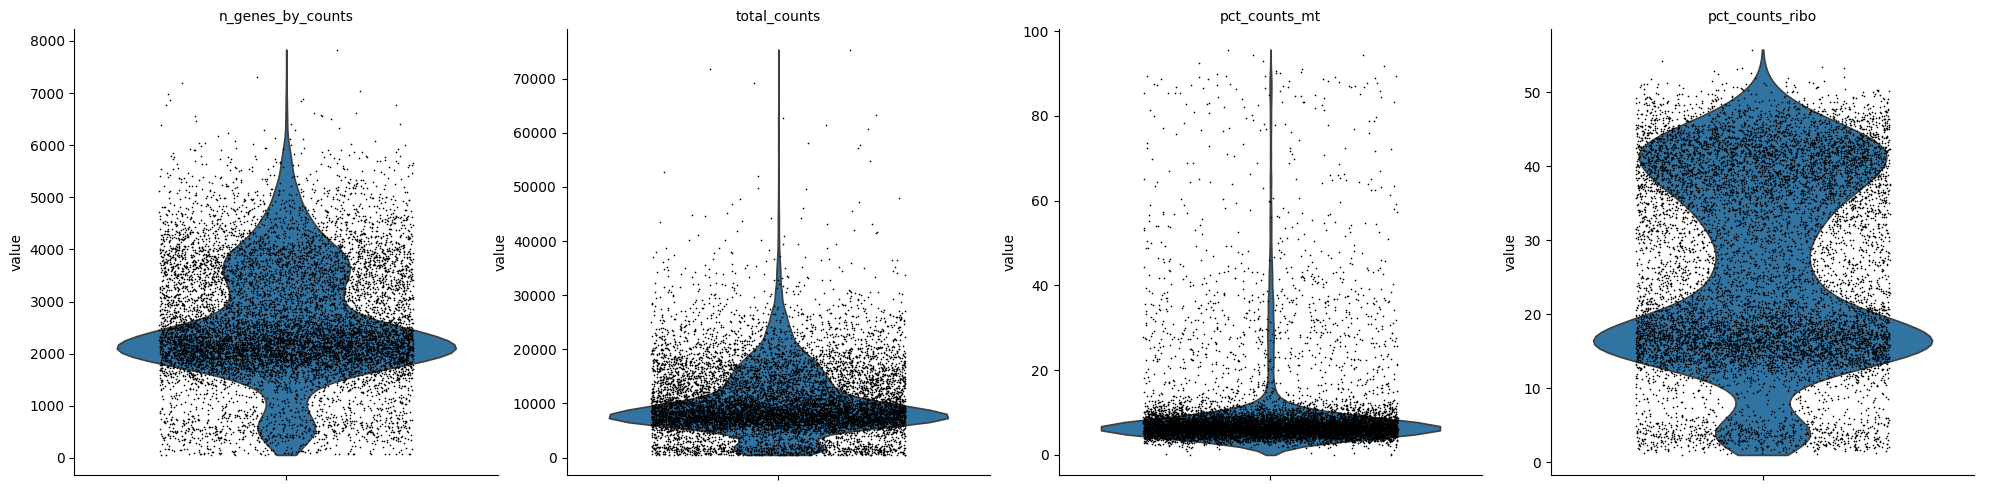

In [8]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt", "pct_counts_ribo"],
    jitter=0.3,
    size=1.2,
    multi_panel=True
)

In [9]:
filter_condition = (adata.obs["n_genes_by_counts"] < 5000) & (adata.obs["pct_counts_mt"] < 20)
adata = adata[filter_condition]
print(f"Filtered {(~filter_condition).sum()} cells")

Filtered 1107 cells


In [10]:
%%time
rsc.pp.filter_genes(adata, min_cells=5)

filtered out 15480 genes that are detected in less than 5 cells
CPU times: user 113 ms, sys: 68.5 ms, total: 182 ms
Wall time: 223 ms


In [11]:
adata

AnnData object with n_obs × n_vars = 9878 × 21121
    obs: 'n_genes_by_counts', 'total_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_mt', 'pct_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'log1p_total_counts_ribo'
    var: 'gene_name', 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'n_cells_by_counts', 'total_counts', 'mean_counts', 'pct_dropout_by_counts', 'log1p_total_counts', 'log1p_mean_counts', 'n_counts', 'n_cells'

## Normalize

In [12]:
%%time
rsc.pp.normalize_total(
    adata,
    target_sum=1e4,
    exclude_highly_expressed=False,
    layer=None,
    inplace=True
)

CPU times: user 1.45 ms, sys: 19 μs, total: 1.47 ms
Wall time: 2.43 ms


In [13]:
%%time
rsc.pp.log1p(
    adata,
    base=None,
    obsm=None,
    layer=None,
    inplace=True
)

CPU times: user 1.02 ms, sys: 7.81 ms, total: 8.82 ms
Wall time: 8.29 ms


In [14]:
%%time
rsc.pp.highly_variable_genes(
    adata,
    n_top_genes=5000,
    min_mean=0.0125,
    max_mean=3,
    min_disp=0.5,
    max_disp=np.inf,
    flavor="cell_ranger",
    n_bins=20,
    span=0.3,
    layer=None,
)

CPU times: user 14.9 ms, sys: 11.6 ms, total: 26.5 ms
Wall time: 33.8 ms


## Clustering

In [15]:
%%time
rsc.tl.pca(
    adata,
    n_comps=50,
    zero_center=True,
    svd_solver="randomized",
    random_state=4,
    use_highly_variable=True,
    chunked=False,
    layer=None,
)

CPU times: user 158 ms, sys: 83.8 ms, total: 242 ms
Wall time: 274 ms


In [16]:
%%time
rsc.pp.neighbors(
    adata,
    n_neighbors=15,
    n_pcs=50,
    algorithm="brute",
    metric="euclidean",
    method="umap",
    use_rep="X_pca",
    random_state=4,
)

CPU times: user 32.2 ms, sys: 40.4 ms, total: 72.6 ms
Wall time: 81.8 ms


In [17]:
%%time
rsc.tl.umap(
    adata,
    min_dist=0.5,
    spread=1.0,
    n_components=2,
    maxiter=100,
    alpha=1.0,
    negative_sample_rate=5,
    init_pos="spectral",
    random_state=4,
    neighbors_key="neighbors",
)

CPU times: user 146 ms, sys: 27.9 ms, total: 174 ms
Wall time: 173 ms


In [18]:
%%time
rsc.tl.leiden(
    adata,
    resolution=1.0,
    random_state=4,
    theta=1.0,
    adjacency=None,
    n_iterations=100,
    use_weights=True,
    neighbors_key="neighbors",
    use_dask=False
)

CPU times: user 1.26 s, sys: 360 ms, total: 1.62 s
Wall time: 1.69 s


In [19]:
adata

AnnData object with n_obs × n_vars = 9878 × 21121
    obs: 'n_genes_by_counts', 'total_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_mt', 'pct_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'log1p_total_counts_ribo', 'leiden'
    var: 'gene_name', 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'n_cells_by_counts', 'total_counts', 'mean_counts', 'pct_dropout_by_counts', 'log1p_total_counts', 'log1p_mean_counts', 'n_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

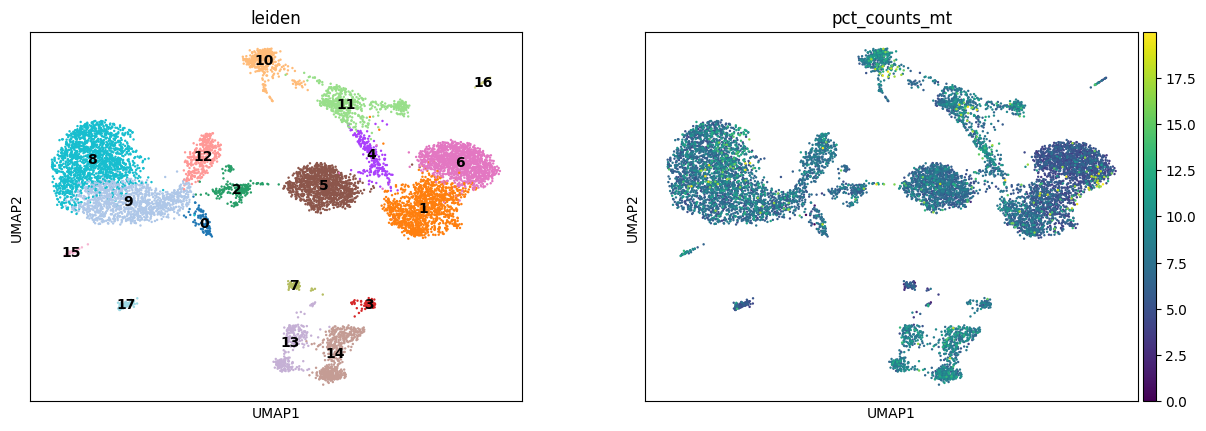

CPU times: user 186 ms, sys: 4.1 ms, total: 190 ms
Wall time: 189 ms


In [20]:
%%time
sc.pl.umap(adata, color=["leiden", "pct_counts_mt"], legend_loc="on data")

# Save results


In [21]:
adata.write(
    os.path.join("data", "pbmc10k_rapids.h5ad"),
)